In [23]:
# 必要ライブラリの読み込み
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [24]:
# MAPの定義と関連する関数、および表示

MAP_WIDTH = 7
MAP_HEIGHT = 7
MAP_COLOR = [
    'white',# 0: Road 通過可能、報酬なし
    'black',# 1: Wall 通ることができない
    'gold' ,# 2: Goal 着いたら報酬を得て終了
]

# MAPの定義
MAP = np.array([[0,0,1,0,0,0,2],
                [1,0,1,0,1,1,0],
                [0,0,0,0,0,1,0],
                [0,1,1,1,0,1,0],
                [0,0,0,1,0,0,0],
                [1,1,0,1,1,1,0],
                [0,0,0,0,0,0,0]])

# 座標 pos = [x, y] に移動可能か判定する関数
def is_movable(pos):
    x = pos[0]
    y = pos[1]
    if x < 0 or x > MAP_WIDTH - 1:
        return False
    if y < 0 or y > MAP_HEIGHT - 1:
        return False
    if MAP[y][x] == 1:
        return False
    return True

# 座標 pos = [x, y] がゴールか判定する関数
def is_goal(pos):
    x = pos[0]
    y = pos[1]
    if MAP[y][x] == 2:
        return True
    return False

In [25]:
# エージェントに関する定義と関数

A_START = [0, 6] #エージェントのスタート位置

#エージェントの位置から状態番号に変換
def pos_to_state(pos):
    return MAP_HEIGHT*pos[0]+pos[1]

# エージェントの状態番号から位置に変換
def state_to_pos(s):
    return [s//MAP_HEIGHT,s%MAP_HEIGHT]

In [26]:
# エージェントの行動に関する関数

# 行動選択関数
# epsilon-greedy法による行動選択
# 確率epsilonでランダムに動きそれ以外はQ値にしたがう
def get_action(s, Q, epsilon):
    num_actions = Q.shape[1]
    if np.random.rand() < epsilon:
        a_next = np.random.choice(range(num_actions))
    else:
        a_next = np.argmax(Q[s,:])
    return a_next

# 次の状態の決定
def get_s_next(s, a):
    [x, y] = state_to_pos(s)
    if a == 0: #up
        y = y - 1
    elif a == 1: #down
        y = y + 1
    elif a == 2: #left
        x = x - 1
    elif a == 3: #right
        x = x + 1
    if is_movable([x, y]): #移動可能な場合のみ移動
        return pos_to_state([x, y])
    else:
        return s

In [30]:
# Q学習関連の関数

# Q学習本体
def Q_learning(s, a, r, s_next, Q, eta):
    GAMMA = 0.99
    if is_goal(state_to_pos(s_next)):
        Q[s,a] = Q[s,a] + eta * (r - Q[s,a])
    else:
        Q[s,a] = Q[s,a] + eta * (r + GAMMA * np.max(Q[s_next,:]) - Q[s,a])
    return Q

# スタートからゴールまでのQ学習
def Q_learning_one_episode(Q, epsilon,eta):
    #初期位置等の設定
    s = pos_to_state(A_START)
    a_next = get_action(s, Q, epsilon)
    s_a_history = [[s, np.nan]]

    #最大300ステップの学習
    for step in range(300):
        #今回の行動による状態遷移とその記録
        a = a_next
        s_a_history[-1][1] = a
        s_next = get_s_next(s, a)
        s_a_history.append([s_next, np.nan])

        # ゴール時のみ報酬を与える
        if is_goal(state_to_pos(s_next)):
            r = 1
        else:
            r = 0

        # 今回のステップでのQ学習を実行
        Q = Q_learning(s, a, r, s_next, Q, eta)

        # ゴール時のみ行動を停止
        if is_goal(state_to_pos(s_next)):
            a_next = np.nan
            break
        else:
            a_next = get_action(s_next, Q, epsilon)
            s = s_next

    return [s_a_history, Q]

[300, 300, 275, 300, 300, 300, 300, 300, 300, 195, 300, 300, 173, 300, 183, 175, 114, 105, 215, 62, 80, 59, 93, 77, 23, 42, 67, 69, 41, 23, 37, 52, 23, 25, 24, 29, 18, 22, 17, 17, 26, 16, 17, 22, 19, 17, 22, 20, 21, 17, 19, 17, 19, 18, 19, 16, 18, 17, 20, 20, 18, 17, 22, 16, 16, 16, 19, 22, 16, 17, 17, 20, 20, 19, 16, 17, 16, 22, 17, 19, 18, 17, 19, 21, 16, 16, 16, 20, 16, 16, 16, 18, 17, 16, 16, 18, 17, 22, 16, 19, 17, 21, 16, 17, 18, 17, 17, 16, 20, 21, 16, 19, 23, 16, 18, 17, 17, 16, 18, 18, 16, 18, 17, 17, 16, 16, 16, 16, 17, 16, 16, 16, 16, 16, 17, 18, 16, 18, 17, 20, 16, 16, 16, 18, 17, 17, 16, 16, 19, 17, 16, 16, 16, 18, 16, 16, 16, 17, 17, 16, 16, 16, 18, 16, 16, 19, 16, 17, 18, 16, 16, 16, 17, 17, 16, 16, 17, 17, 18, 16, 17, 16, 18, 17, 16, 16, 18, 19, 18, 22, 16, 16, 16, 19, 18, 16, 18, 18, 16, 17, 17, 19, 16, 16, 17, 16, 16, 16, 18, 16, 16, 18, 16, 19, 18, 16, 16, 16, 16, 18, 17, 16, 16, 16, 18, 16, 16, 16, 18, 17, 18, 16, 17, 16, 20, 17, 16, 17, 16, 16, 16, 16, 16, 16, 16, 

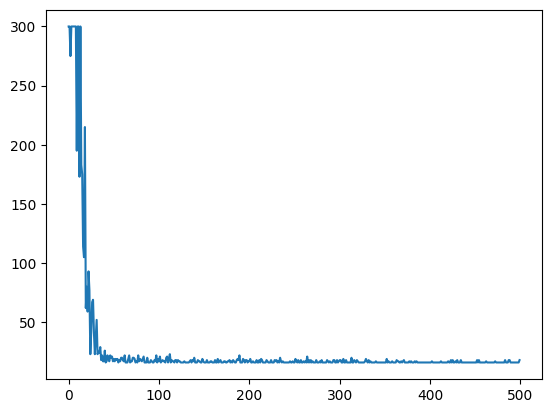

In [31]:
# Q学習を実行

MAX_EPISODE = 500 #最大学習エピソード回数
num_states = MAP_WIDTH * MAP_HEIGHT #状態最大数（エージェントの迷路での位置）
num_actions = 4 #上下左右の行動
Qtable = np.random.rand(num_states,num_actions) #Q関数のランダムな初期化
Q_learning_history = [] #Q学習による学習状況（ゴールまでの到達ステップ数）を記録

for episode in range(MAX_EPISODE):
    epsilon = 0.5 / ((episode /20) + 1) #乱数行動の選択確率、徐々に減少
    eta = 0.1 #学習のステップ幅

    [s_a_history, Qtable] = Q_learning_one_episode(Qtable,epsilon,eta)
    Q_learning_history.append(len(s_a_history)-1)

# Q学習の学習曲線表示
print(Q_learning_history)
plt.plot(range(MAX_EPISODE),Q_learning_history)

number of steps:16


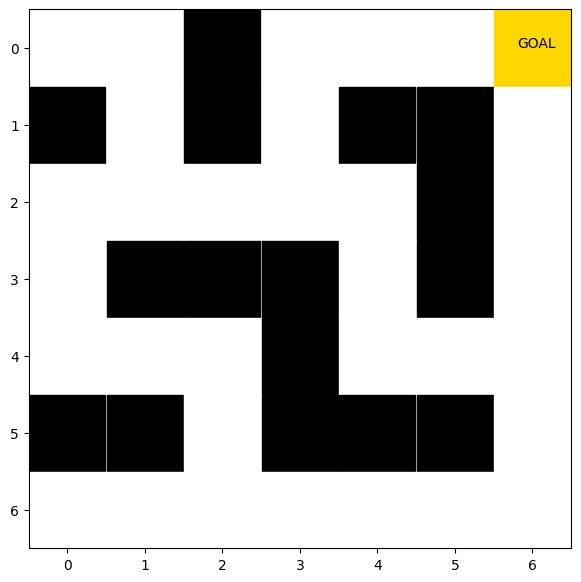

In [32]:
# 最終結果のアニメーションの表示

# 必要ライブラリの読み込み

from matplotlib import animation
from IPython.display import HTML

# マップの表示設定
fig = plt.figure(figsize=(MAP_WIDTH,MAP_HEIGHT))
ax = plt.gca()
ax.set_xlim(-0.5,MAP_WIDTH-0.5)
ax.set_ylim(MAP_HEIGHT-0.5,-0.5)
for i in range(MAP_HEIGHT):
    for j in range(MAP_WIDTH):
        ax.plot(j,i, marker='s', color = MAP_COLOR[MAP[i][j]], markersize=55)
        if(MAP[i][j]==2):
            ax.text(j-0.2,i,'GOAL')

# 最終経路の再計算
[history, final_Qtable] = Q_learning_one_episode(Qtable,0,0)
print("number of steps:" + str(len(history)-1))

# 各時点での画像の作成
ims = []
for i in range(len(history)):
    s = history[i][0]
    [x, y] = state_to_pos(s)
    p = ax.plot(x, y, marker='o', color='green', markersize=40)
    ims.append(p)

# アニメーション作成と表示
anim = animation.ArtistAnimation(fig, ims, interval=300, repeat=False)
# anim.save("anim.mp4") #アニメーションファイルの保存をする場合
HTML(anim.to_jshtml())